# EDA

## Load packages

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split # splitting data into train/validation/test sets
from sklearn.preprocessing import StandardScaler # splitting data into train/validation/test sets
from sklearn.metrics import ( # feature standardization
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
    classification_report,
    confusion_matrix,
    brier_score_loss
)
# average precision, precision-recall tools, and Brier score -> imbalanced classification problem
# plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## Load data

In [5]:
df = pd.read_csv("creditcard.csv")

print(df.shape)
print(df.head())
print(df["Class"].value_counts(normalize=True))

(284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7        V8        V9       V10       V11  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599  0.098698  0.363787  0.090794 -0.551600   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803  0.085102 -0.255425 -0.166974  1.612727   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461  0.247676 -1.514654  0.207643  0.624501   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609  0.377436 -1.387024 -0.054952 -0.226487   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941 -0.270533  0.817739  0.753074 -0.822843   

        V12       V13       V14       V15       V16       V17       V18       V19       V20       V21       V22  \
0 -0.617801 -0.991390 -0.311169  1.468177 -0.470401  0.207971  0.025791  0.403993  0.251412 -0.018307  0.277838   
1  1.065235  0.489095 -0.14377

- Kaggle credit card fraud dataset https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud/data

Dataset characteristics:

- 284,807 transactions
- Only 492 fraud cases
- 29 features (mostly PCA-transformed)

## Basic checks

In [8]:
print("\nMissing values:\n", df.isna().sum().sum())
print("\nClass counts:\n", df["Class"].value_counts())
print("\nFraud rate:", df["Class"].mean())


Missing values:
 0

Class counts:
 Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.001727485630620034


## Feature engineering

In [10]:
# Keep original Amount and add a log-transformed version
df["LogAmount"] = np.log1p(df["Amount"])

# Keep Time for now; we can test whether it adds value
features = [col for col in df.columns if col != "Class"]
target = "Class"

X = df[features].copy()
y = df[target].copy()

EDA:

- Amount is highly skewed
- Long tail → large values distort models

Log transform:

- Reduces skewness
- Makes relationships more linear
- Improves model stability

## Train / validation / test split

In [13]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.15,
    stratify=y,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.1765,   # makes ~15% validation overall
    stratify=y_train_full,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("Test shape:", X_test.shape)

print("\nFraud rate by split:")
print("Train:", y_train.mean())
print("Val:  ", y_val.mean())
print("Test: ", y_test.mean())

Train shape: (199356, 31)
Val shape: (42729, 31)
Test shape: (42722, 31)

Fraud rate by split:
Train: 0.0017255562912578504
Val:   0.0017318448828664373
Test:  0.0017321286456626562


train → 70%

validation → 15%

test → 15%

## Scale features

In [16]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_val_scaled = pd.DataFrame(
    scaler.transform(X_val),
    columns=X_val.columns,
    index=X_val.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print(X_train_scaled.head())

            Time        V1        V2        V3        V4        V5        V6        V7        V8        V9       V10  \
158731  0.353086  1.129058 -0.235493 -1.164514 -0.439925 -0.208263 -1.200231 -0.082131 -0.377533 -0.521745  0.261673   
146582 -0.150338 -1.513941  1.646024 -0.746530 -2.015755 -0.261806 -0.955792  0.117168  1.006311  0.300910  0.087552   
204074  0.845777 -0.130612  0.695732 -0.616270 -0.479040  0.524306 -0.250198  0.458774  0.413707 -0.377553 -0.826880   
67579  -0.890333 -1.303592 -0.174707  0.089173  0.393838 -0.628248 -1.065065 -0.200632  0.269710 -2.080088  0.750161   
196916  0.775423  0.998107 -0.429818 -1.191636 -0.558351  1.292626  2.793505 -0.852682  0.835003  0.787187  0.007923   

             V11       V12       V13       V14       V15       V16       V17       V18       V19       V20       V21  \
158731 -0.267478 -0.502063  0.307539 -1.381226 -0.247735  1.146903  1.574195 -1.640701  0.782312  0.007967 -0.047190   
146582  0.410656  1.733490  0.947684  0

For logistic regression:

- Model assumes features are on similar scale
- Without scaling:
    - coefficients become unstable
    - optimization slows down
    
For Bayesian models

- Priors (e.g., Normal(0,1)) assume standardized inputs
- Without scaling:
    - priors become meaningless
    - inference becomes unstable

# Baseline Models

In [19]:
required_objects = ["X_train_scaled", "X_val_scaled", "X_test_scaled", "y_train", "y_val", "y_test"]
for obj_name in required_objects:
    if obj_name not in globals():
        raise NameError(f"{obj_name} is not defined.")

print("Training shape:", X_train_scaled.shape)
print("Validation shape:", X_val_scaled.shape)
print("Test shape:", X_test_scaled.shape)

print("\nFraud rates:")
print("Train:", y_train.mean())
print("Val:  ", y_val.mean())
print("Test: ", y_test.mean())


Training shape: (199356, 31)
Validation shape: (42729, 31)
Test shape: (42722, 31)

Fraud rates:
Train: 0.0017255562912578504
Val:   0.0017318448828664373
Test:  0.0017321286456626562


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    brier_score_loss,
    precision_recall_curve,
    roc_curve,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_style("whitegrid")

## Helper functions

In [22]:
def evaluate_probabilities(y_true, y_prob, threshold=0.5):
    """
    Evaluate classification probabilities at a chosen threshold.
    Returns a dictionary of useful rare-event classification metrics.
    """
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "threshold": threshold,
        "average_precision": average_precision_score(y_true, y_prob),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "brier_score": brier_score_loss(y_true, y_prob),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0)
    }

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    metrics["tn"] = tn
    metrics["fp"] = fp
    metrics["fn"] = fn
    metrics["tp"] = tp

    return metrics

'''
Function evaluates model probabilities at a chosen threshold and returns both threshold-independent metrics, 
like average precision and ROC-AUC, and threshold-dependent metrics, like precision, recall, F1, and confusion matrix counts. Evaluate all models consistently.
'''

def find_best_f1_threshold(y_true, y_prob):
    """
    Find threshold that maximizes F1 on validation data.
    """
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)

    # precision_recall_curve returns one extra precision/recall point
    thresholds = np.append(thresholds, 1.0)

    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-12)

    best_idx = np.argmax(f1_scores)

    return {
        "best_threshold": thresholds[best_idx],
        "best_f1": f1_scores[best_idx],
        "precision_at_best_f1": precision[best_idx],
        "recall_at_best_f1": recall[best_idx]
    }

'''
Did not assume the default 0.5 threshold was optimal. 
This function searches across thresholds and finds the one that maximizes F1, 
which is useful when you want a balanced tradeoff between catching fraud and limiting false alarms.
'''

def find_threshold_for_target_precision(y_true, y_prob, target_precision=0.80):
    """
    Find the first threshold that achieves at least the target precision.
    Among eligible thresholds, choose the one with highest recall.
    """
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    thresholds = np.append(thresholds, 1.0)

    eligible = np.where(precision >= target_precision)[0]

    if len(eligible) == 0:
        return None

    best_idx = eligible[np.argmax(recall[eligible])]

    return {
        "threshold": thresholds[best_idx],
        "precision": precision[best_idx],
        "recall": recall[best_idx]
    }

'''
This function supports a policy-driven threshold. 
Instead of optimizing a generic metric, it enforces a business rule like minimum 80% precision 
and then finds the threshold with the highest recall under that constraint.
'''

def expected_cost_from_threshold(y_true, y_prob, threshold, cost_fp=1, cost_fn=25):
    """
    Compute expected operational cost for a chosen threshold.
    """
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    total_cost = fp * cost_fp + fn * cost_fn

    return {
        "threshold": threshold,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "tn": tn,
        "cost_fp": cost_fp,
        "cost_fn": cost_fn,
        "total_cost": total_cost
    }

'''
This function supports a policy-driven threshold. Instead of optimizing a generic metric, 
it enforces a business rule like minimum 80% precision and then finds the threshold with 
the highest recall under that constraint.
'''

def search_cost_optimal_threshold(y_true, y_prob, cost_fp=1, cost_fn=25, n_grid=200):
    """
    Search over thresholds to minimize expected cost.
    """
    candidate_thresholds = np.linspace(0.001, 0.999, n_grid)

    results = []
    for t in candidate_thresholds:
        out = expected_cost_from_threshold(y_true, y_prob, t, cost_fp=cost_fp, cost_fn=cost_fn)
        results.append(out)

    results_df = pd.DataFrame(results)
    best_row = results_df.loc[results_df["total_cost"].idxmin()].to_dict()

    return results_df, best_row

'''
Grid search over thresholds to identify the cost-minimizing operating point. 
Compare thresholds not just by technical metrics, but by their likely business impact.
'''

def plot_precision_recall_curves(results_dict, y_true):
    """
    Plot precision-recall curves for multiple models.
    results_dict = {"model_name": y_prob_array}
    """
    plt.figure(figsize=(8, 6))

    for model_name, y_prob in results_dict.items():
        precision, recall, _ = precision_recall_curve(y_true, y_prob)
        ap = average_precision_score(y_true, y_prob)
        plt.plot(recall, precision, label=f"{model_name} (AP={ap:.4f})")

    baseline = y_true.mean()
    plt.axhline(y=baseline, linestyle="--", label=f"Fraud Rate Baseline ({baseline:.4f})")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curves on Validation Set")
    plt.legend()
    plt.show()
    
'''
Precision-recall curves because this is an extreme rare-event problem. 
They show how precision changes as recall increases (more informative than accuracy).
'''

def plot_roc_curves(results_dict, y_true):
    """
    Plot ROC curves for multiple models.
    """
    plt.figure(figsize=(8, 6))

    for model_name, y_prob in results_dict.items():
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc = roc_auc_score(y_true, y_prob)
        plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc:.4f})")

    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves on Validation Set")
    plt.legend()
    plt.show()

**Average precision** summarizes the precision-recall curve and is better suited than accuracy for rare-event problems because it focuses on how well the model ranks the positive class.

**Threshold 0.5** is arbitrary. In imbalanced problems, the threshold should reflect either the metric we care about, like F1, or the business tradeoff between false positives and false negatives.

**Brier score** measures the quality of predicted probabilities, not just final class labels. Since this project is probability-based and includes threshold tuning, probability calibration matters.

## Train baseline logistic regression

In [25]:
baseline_logreg = LogisticRegression(
    penalty="l2", # ridge regularization
    C=1.0, # default regularization strength
    solver="liblinear", # stable solver for smaller/medium classification problems
    max_iter=1000, # enough iterations to converge
    random_state=42
)

baseline_logreg.fit(X_train_scaled, y_train)

val_prob_baseline = baseline_logreg.predict_proba(X_val_scaled)[:, 1]
test_prob_baseline = baseline_logreg.predict_proba(X_test_scaled)[:, 1]

baseline_val_metrics_05 = evaluate_probabilities(y_val, val_prob_baseline, threshold=0.5)
baseline_val_metrics_05

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


{'threshold': 0.5,
 'average_precision': 0.7726931642422097,
 'roc_auc': 0.9829169927165474,
 'brier_score': 0.0006553952759388054,
 'precision': 0.9,
 'recall': 0.6081081081081081,
 'f1': 0.7258064516129032,
 'tn': 42650,
 'fp': 5,
 'fn': 29,
 'tp': 45}

- Threshold = 0.5 (default classification cutoff)
    - if predicted fraud probability ≥ 0.5 → classify as fraud
    - otherwise → classify as non-fraud

- Average Precision = 0.7727 (very strong for an extremely imbalanced dataset)
    - It means the model ranks fraud cases well across the precision-recall tradeoff.
    - AP is one of the most important metrics here it reflects performance on the positive class better than accuracy

- ROC-AUC = 0.9829 (very high) the model separates fraud and non-fraud well overall.
    - ROC-AUC can look overly optimistic in highly imbalanced problems

- Brier Score = 0.000655 (very low, which is good)
    - Brier score measures the accuracy of predicted probabilities.
    - A lower value means: predicted probabilities are closer to true outcomes on average
    
- Precision = 0.90 (among all transactions the model flagged as fraud, 90% were actually fraud)
- Recall = 0.6081 (the model catches about 61% of actual frauds)
    - about 39% of fraud cases are missed (this is the first sign that threshold 0.5 may be too strict for this use case)
    
- F1 = 0.7258 (harmonic mean of precision and recall)
- It tells you the model has a reasonably strong balance between:
    - being accurate when it flags fraud
    - catching fraud cases
    - A strong F1 here suggests the baseline is already good.
    
### Confusion matrix interpretation
- TP = 45 → frauds correctly identified
- FP = 5 → legitimate transactions incorrectly flagged as fraud
- FN = 29 → frauds missed
- TN = 42650 → legitimate transactions correctly left alone

**This baseline model is highly precise:**
- it only made 5 false alarms
- missed 29 fraud cases, which may be costly in a real setting
- At the default threshold, the baseline model produced very few false positives, only 5, but it still missed 29 fraud cases. That suggests the model is conservative and supports later threshold tuning to improve recall

**This baseline model:**
- it protects customer experience by minimizing false alarms
- but it may under-detect fraud

**Next:**
- weighted logistic regression
- threshold optimization
- Bayesian analysis

## Train class-weighted logistic regression

In [28]:
weighted_logreg = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="liblinear",
    class_weight="balanced", # It automatically assigns higher weight to the minority class (fraud samples get much higher penalty if misclassified)
    max_iter=1000,
    random_state=42
)

weighted_logreg.fit(X_train_scaled, y_train)

val_prob_weighted = weighted_logreg.predict_proba(X_val_scaled)[:, 1]
test_prob_weighted = weighted_logreg.predict_proba(X_test_scaled)[:, 1]

weighted_val_metrics_05 = evaluate_probabilities(y_val, val_prob_weighted, threshold=0.5)
weighted_val_metrics_05

{'threshold': 0.5,
 'average_precision': 0.7523997275432266,
 'roc_auc': 0.9859485437846708,
 'brier_score': 0.0214986692253928,
 'precision': 0.068,
 'recall': 0.918918918918919,
 'f1': 0.12662942271880823,
 'tn': 41723,
 'fp': 932,
 'fn': 6,
 'tp': 68}

## Compare models at threshold = 0.5

- average precision
- ROC-AUC
- Brier score
- precision, recall, F1
- confusion matrix counts

In [30]:
comparison_df = pd.DataFrame([
    {"model": "Baseline Logistic", **baseline_val_metrics_05},
    {"model": "Weighted Logistic", **weighted_val_metrics_05}
])

comparison_df = comparison_df[
    ["model", "threshold", "average_precision", "roc_auc", "brier_score",
     "precision", "recall", "f1", "tp", "fp", "fn", "tn"]
]

comparison_df.sort_values(by="average_precision", ascending=False)

,model,threshold,average_precision,roc_auc,brier_score,precision,recall,f1,tp,fp,fn,tn
0,Baseline Logistic,0.5,0.772693,0.982917,0.000655,0.900,0.608108,0.725806,45,5,29,42650
1,Weighted Logistic,0.5,0.752400,0.985949,0.021499,0.068,0.918919,0.126629,68,932,6,41723


1. Recall jumps massively
- From 61% → 92%
- Model now catches almost all fraud

2. Precision collapses
- From 90% → 6.8%
- almost all flagged transactions are false alarms

3. False positives explode
- From 5 → 932
- This is the biggest change; poor customer experience

4. False negatives drop significantly
- From 29 → 6
- you miss far fewer fraud cases

5. F1 score drops heavily
- From 0.73 → 0.13
- F1 penalizes imbalance between precision and recall

6. ROC-AUC slightly improves
- 0.9829 → 0.9859
- model ranking ability improved slightly
- decision quality got worse at threshold 0.5

7. Brier score worsens significantly
- 0.00065 → 0.0215
- predicted probabilities are less reliable

## Plot PR and ROC curves on validation data

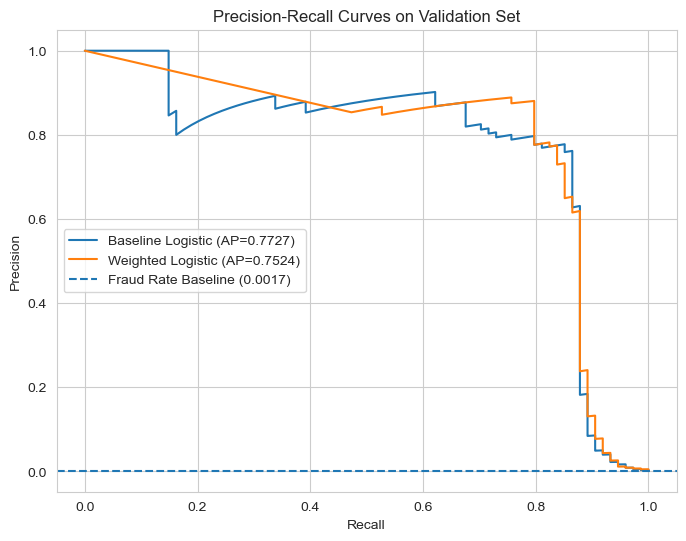

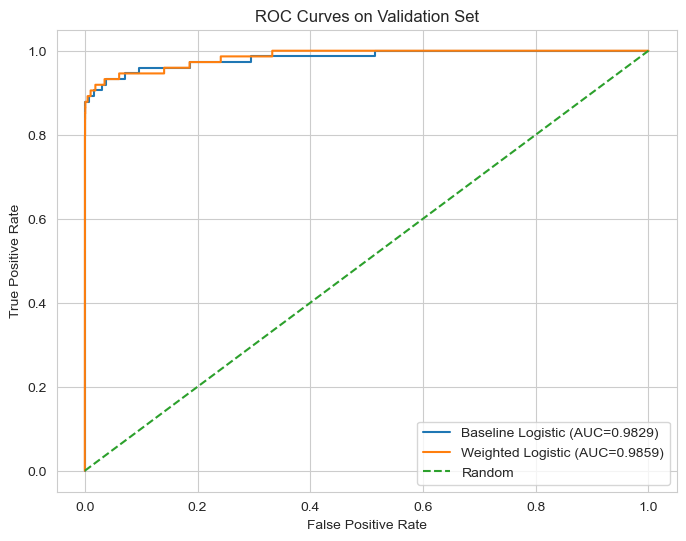

In [33]:
val_results = {
    "Baseline Logistic": val_prob_baseline,
    "Weighted Logistic": val_prob_weighted
}

plot_precision_recall_curves(val_results, y_val)
plot_roc_curves(val_results, y_val)

## Find validation threshold that maximizes F1

In [35]:
baseline_best_f1 = find_best_f1_threshold(y_val, val_prob_baseline)
weighted_best_f1 = find_best_f1_threshold(y_val, val_prob_weighted)

pd.DataFrame([
    {"model": "Baseline Logistic", **baseline_best_f1},
    {"model": "Weighted Logistic", **weighted_best_f1}
])

,model,best_threshold,best_f1,precision_at_best_f1,recall_at_best_f1
0,Baseline Logistic,0.07537,0.812903,0.777778,0.851351
1,Weighted Logistic,1.00000,0.836879,0.880597,0.797297


## Find threshold for target precision

In [37]:
baseline_target_precision = find_threshold_for_target_precision(
    y_val, val_prob_baseline, target_precision=0.80
)

weighted_target_precision = find_threshold_for_target_precision(
    y_val, val_prob_weighted, target_precision=0.80
)

pd.DataFrame([
    {"model": "Baseline Logistic", **(baseline_target_precision or {})},
    {"model": "Weighted Logistic", **(weighted_target_precision or {})}
])

,model,threshold,precision,recall
0,Baseline Logistic,0.233900,0.800000,0.756757
1,Weighted Logistic,0.999999,0.808219,0.797297


## Cost-based threshold search

Finds a threshold meeting a business-friendly precision target.

In [39]:
# Example business assumption:
# Missing a fraud case is 25x as costly as investigating a false alarm.
baseline_cost_grid, baseline_best_cost = search_cost_optimal_threshold(
    y_val, val_prob_baseline, cost_fp=1, cost_fn=25, n_grid=200
)

weighted_cost_grid, weighted_best_cost = search_cost_optimal_threshold(
    y_val, val_prob_weighted, cost_fp=1, cost_fn=25, n_grid=200
)

pd.DataFrame([
    {"model": "Baseline Logistic", **baseline_best_cost},
    {"model": "Weighted Logistic", **weighted_best_cost}
]).sort_values("total_cost")

,model,threshold,fp,fn,tp,tn,cost_fp,cost_fn,total_cost
1,Weighted Logistic,0.983955,40.0,9.0,65.0,42615.0,1.0,25.0,265.0
0,Baseline Logistic,0.021060,41.0,9.0,65.0,42614.0,1.0,25.0,266.0


## Visualize cost vs threshold

Finds a cost-minimizing threshold based on false-positive and false-negative costs.

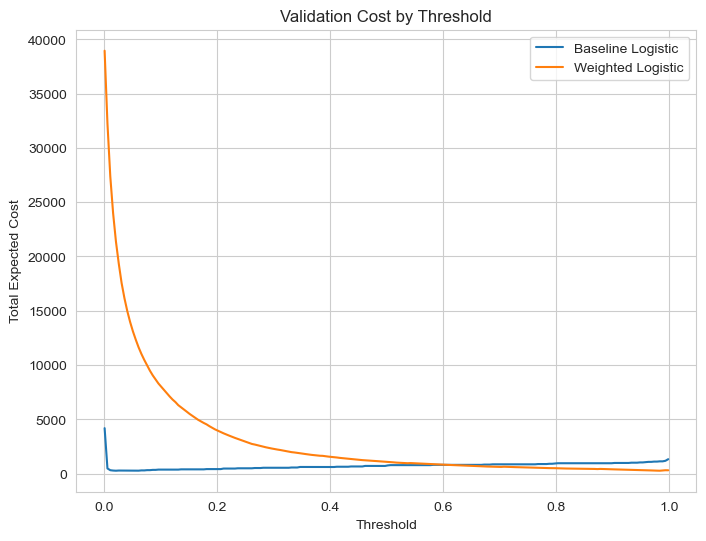

In [41]:
plt.figure(figsize=(8, 6))
plt.plot(baseline_cost_grid["threshold"], baseline_cost_grid["total_cost"], label="Baseline Logistic")
plt.plot(weighted_cost_grid["threshold"], weighted_cost_grid["total_cost"], label="Weighted Logistic")
plt.xlabel("Threshold")
plt.ylabel("Total Expected Cost")
plt.title("Validation Cost by Threshold")
plt.legend()
plt.show()

## Choose final validation-selected thresholds

Evaluates those threshold choices on the test set.


In [43]:
# Choose one policy for each model.
# Store three policy thresholds:
selected_thresholds = {
    "baseline_05": 0.5,
    "weighted_05": 0.5,
    "baseline_best_f1": baseline_best_f1["best_threshold"],
    "weighted_best_f1": weighted_best_f1["best_threshold"],
    "baseline_best_cost": baseline_best_cost["threshold"],
    "weighted_best_cost": weighted_best_cost["threshold"]
}

selected_thresholds

{'baseline_05': 0.5,
 'weighted_05': 0.5,
 'baseline_best_f1': 0.07536993413365738,
 'weighted_best_f1': 0.9999999997056797,
 'baseline_best_cost': 0.02106030150753769,
 'weighted_best_cost': 0.9839547738693467}

## Evaluate chosen thresholds on test data

In [45]:
test_results = []

for threshold_name, threshold_value in selected_thresholds.items():
    if "baseline" in threshold_name:
        metrics = evaluate_probabilities(y_test, test_prob_baseline, threshold=threshold_value)
        test_results.append({"model_policy": threshold_name, **metrics})
    elif "weighted" in threshold_name:
        metrics = evaluate_probabilities(y_test, test_prob_weighted, threshold=threshold_value)
        test_results.append({"model_policy": threshold_name, **metrics})

test_results_df = pd.DataFrame(test_results)

test_results_df = test_results_df[
    ["model_policy", "threshold", "average_precision", "roc_auc", "brier_score",
     "precision", "recall", "f1", "tp", "fp", "fn", "tn"]
]

test_results_df.sort_values(by="f1", ascending=False)

'''
selected_thresholds contains policies such as:

baseline_05
baseline_best_f1
baseline_best_cost
weighted_05
weighted_best_f1
weighted_best_cost

For each chosen operating policy, evaluate how it performs on unseen test data.
'''

'\nselected_thresholds contains policies such as:\n\nbaseline_05\nbaseline_best_f1\nbaseline_best_cost\nweighted_05\nweighted_best_f1\nweighted_best_cost\n\nFor each chosen operating policy, evaluate how it performs on unseen test data.\n'

**The best-performing model depends on the decision objective:**

- best balanced classification:
    - weighted_best_f1 is best
- strong simple default:
    - baseline_05 is excellent
- catching fraud:
    - cost-based thresholds give higher recall
- If you use a weighted model without threshold tuning:
    - performance is poor operationally

## Classification report for the best test policy

In [48]:
best_policy_name = test_results_df.sort_values(by="f1", ascending=False).iloc[0]["model_policy"]

if "baseline" in best_policy_name:
    best_threshold = test_results_df.loc[test_results_df["model_policy"] == best_policy_name, "threshold"].iloc[0]
    best_test_pred = (test_prob_baseline >= best_threshold).astype(int)
else:
    best_threshold = test_results_df.loc[test_results_df["model_policy"] == best_policy_name, "threshold"].iloc[0]
    best_test_pred = (test_prob_weighted >= best_threshold).astype(int)

print("Best policy:", best_policy_name)
print("Threshold:", round(best_threshold, 4))
print("\nClassification report:\n")
print(classification_report(y_test, best_test_pred, digits=4, zero_division=0))

Best policy: weighted_best_f1
Threshold: 1.0

Classification report:

              precision    recall  f1-score   support

           0     0.9996    0.9997    0.9996     42648
           1     0.8028    0.7703    0.7862        74

    accuracy                         0.9993     42722
   macro avg     0.9012    0.8850    0.8929     42722
weighted avg     0.9993    0.9993    0.9993     42722



## Inspect coefficients

Shows which features matter most in the weighted logistic model.

In [50]:
coef_df = pd.DataFrame({
    "feature": X_train_scaled.columns,
    "baseline_coef": baseline_logreg.coef_[0],
    "weighted_coef": weighted_logreg.coef_[0]
})

coef_df["abs_weighted_coef"] = coef_df["weighted_coef"].abs()

coef_df.sort_values("abs_weighted_coef", ascending=False).head(15)

,feature,baseline_coef,weighted_coef,abs_weighted_coef
29,Amount,0.218458,2.699240,2.699240
1,V1,0.172193,2.107085,2.107085
10,V10,-0.860334,-1.871990,1.871990
14,V14,-0.523086,-1.555147,1.555147
4,V4,0.942350,1.384398,1.384398
5,V5,0.207595,1.330591,1.330591
12,V12,0.031497,-1.305064,1.305064
20,V20,-0.353580,-1.187211,1.187211
7,V7,-0.129522,-1.148040,1.148040
17,V17,-0.055123,-1.141135,1.141135


## Plot top weighted coefficients

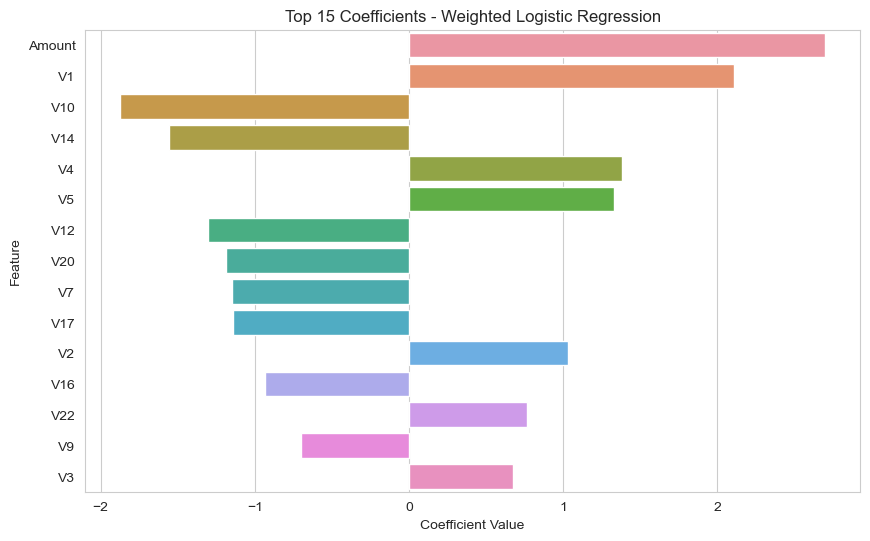

In [52]:
top_features = coef_df.sort_values("abs_weighted_coef", ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_features, x="weighted_coef", y="feature")
plt.title("Top 15 Coefficients - Weighted Logistic Regression")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()

# Bayesian Logistic Regression

- fit a Bayesian logistic regression
- use shrinkage priors instead of the older prior setup
- generate posterior summaries
- produce posterior predictive probabilities
- evaluate on validation and test data
- compare against baseline models

In [54]:
import pymc as pm
import arviz as az
import numpy as np

## Use top features from weighted logistic

In [56]:
# Use top 12 most important features from the weighted logistic regression
top_n = 12
bayes_features = (
    coef_df.sort_values("abs_weighted_coef", ascending=False)
    .head(top_n)["feature"]
    .tolist()
)

bayes_features

['Amount',
 'V1',
 'V10',
 'V14',
 'V4',
 'V5',
 'V12',
 'V20',
 'V7',
 'V17',
 'V2',
 'V16']

## Create modeling matrices

In [58]:
X_train_bayes = X_train_scaled[bayes_features].copy()
X_val_bayes = X_val_scaled[bayes_features].copy()
X_test_bayes = X_test_scaled[bayes_features].copy()

y_train_bayes = y_train.copy()
y_val_bayes = y_val.copy()
y_test_bayes = y_test.copy()

print("Bayesian training shape:", X_train_bayes.shape)
print("Bayesian validation shape:", X_val_bayes.shape)
print("Bayesian test shape:", X_test_bayes.shape)

Bayesian training shape: (199356, 12)
Bayesian validation shape: (42729, 12)
Bayesian test shape: (42722, 12)


## Downsampling for MCMC speed

In [60]:
# training downsampling for MCMC speed
# keep all frauds, sample non-frauds
train_df_bayes = X_train_bayes.copy()
train_df_bayes["Class"] = y_train_bayes.values

fraud_df = train_df_bayes[train_df_bayes["Class"] == 1]
nonfraud_df = train_df_bayes[train_df_bayes["Class"] == 0]

print("Original fraud count:", len(fraud_df))
print("Original non-fraud count:", len(nonfraud_df))

# Adjust ratio as needed
nonfraud_sample = nonfraud_df.sample(
    n=min(len(nonfraud_df), len(fraud_df) * 10),
    random_state=42
)

train_df_bayes_sampled = pd.concat([fraud_df, nonfraud_sample], axis=0).sample(frac=1, random_state=42)

X_train_bayes_sampled = train_df_bayes_sampled.drop(columns="Class")
y_train_bayes_sampled = train_df_bayes_sampled["Class"]

print("Sampled training shape:", X_train_bayes_sampled.shape)
print("Sampled fraud rate:", y_train_bayes_sampled.mean())

Original fraud count: 344
Original non-fraud count: 199012
Sampled training shape: (3784, 12)
Sampled fraud rate: 0.09090909090909091


- selects the strongest predictors from the earlier weighted logistic model
- creates Bayesian train/validation/test feature sets
- keeps all fraud cases in the training data
- downsamples the majority class


- Full Bayesian inference on the entire dataset is computationally heavy. 

    - the training set is intentionally rebalanced
    - validation and test sets remain unchanged
    - the Bayesian model is trained on a subset but evaluated on realistic held-out data

To make Bayesian inference feasible on a large, highly imbalanced dataset, I selected the most informative features and used all fraud cases plus a sample of non-fraud cases in training. I kept the validation and test sets unchanged so evaluation remained realistic.

# Bayesian logistic regression model

1. **MCMC**
- Samples from the true posterior
- More accurate
- Slower and sometimes unstable (divergences)

2. **ADVI**
- Uses variational inference
- Approximates the posterior with a simpler distribution
- Much faster and more stable (computational efficiency)

## Bayesian logistic regression with shrinkage

In [65]:
# Converts the pandas DataFrames into NumPy arrays for PyMC
X_train_np = X_train_bayes_sampled.values
y_train_np = y_train_bayes_sampled.values
X_val_np = X_val_bayes.values
X_test_np = X_test_bayes.values

n_features = X_train_np.shape[1]

/Users/karolina/opt/anaconda3/lib/python3.9/site-packages/pymc/data.py:434: UserWarning: The `mutable` kwarg was not specified. Before v4.1.0 it defaulted to `pm.Data(mutable=True)`, which is equivalent to using `pm.MutableData()`. In v4.1.0 the default changed to `pm.Data(mutable=False)`, equivalent to `pm.ConstantData`. Use `pm.ConstantData`/`pm.MutableData` or pass `pm.Data(..., mutable=False/True)` to avoid this warning.
  warnings.warn(


## Fit model with NUTS / MCMC

# ADVI

In [69]:
with pm.Model() as bayes_logistic_model:
    X_data = pm.ConstantData("X_data", X_train_np)
    y_data = pm.ConstantData("y_data", y_train_np)

    alpha = pm.Normal("alpha", mu=0.0, sigma=2.0)
    beta = pm.Normal("beta", mu=0.0, sigma=0.5, shape=n_features)

    logits = alpha + pm.math.dot(X_data, beta)

    y_obs = pm.Bernoulli("y_obs", logit_p=logits, observed=y_data)
    p = pm.Deterministic("p", pm.math.sigmoid(logits))

- alpha: intercept prior
- beta: priors for regression coefficients
- logits: linear predictor
- y_obs: Bernoulli likelihood
- p: predicted fraud probability


**translate the fraud detection problem into a probabilistic model**
- Instead of fitting one fixed coefficient vector, it places priors on the coefficients and estimates a posterior distribution over them.

Bayesian logistic regression model. Fraud labels are modeled as Bernoulli outcomes, and the log-odds of fraud are expressed as a linear function of the predictors. Normal priors on the intercept and coefficients, which regularizes the model and reflects uncertainty in the parameter values.

In [71]:
# Bayesian model using ADVI (variational inference)
with bayes_logistic_model:
    approx = pm.fit(
        n=20000,
        method="advi",
        random_seed=42,
        progressbar=True
    )
    trace_vi = approx.sample(1000)

Finished [100%]: Average Loss = 269.49


In [72]:
# Sample posterior draws from the variational approximation
trace_vi = approx.sample(1000)

# Quick summary
summary_vi = az.summary(trace_vi, var_names=["alpha", "beta"], round_to=4)
summary_vi

arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-4.9283,0.1669,-5.2489,-4.6166,0.0052,0.0037,1030.8309,942.0177,NaN
beta[0],0.7423,0.0913,0.5754,0.9112,0.0031,0.0022,862.0732,800.4990,NaN
beta[1],0.2535,0.1007,0.0582,0.4285,0.0034,0.0024,859.7763,842.5659,NaN
beta[2],-0.4928,0.1074,-0.6816,-0.2862,0.0033,0.0024,1040.1441,917.4033,NaN
beta[3],-0.7053,0.0718,-0.8477,-0.5816,0.0023,0.0016,1004.0402,981.1805,NaN
beta[4],0.8663,0.0881,0.7189,1.0443,0.0028,0.0020,1014.7710,994.6728,NaN
beta[5],0.4334,0.0864,0.2850,0.6013,0.0028,0.0020,925.9429,848.7930,NaN
beta[6],-0.3162,0.0973,-0.5116,-0.1469,0.0032,0.0022,964.2663,936.7700,NaN
beta[7],-0.4439,0.0824,-0.5992,-0.2940,0.0027,0.0019,942.7665,777.4981,NaN
beta[8],-0.2352,0.0872,-0.3952,-0.0715,0.0028,0.0020,938.3281,977.6814,NaN


In [73]:
# extract posterior draws
posterior = trace_vi.posterior

alpha_draws = posterior["alpha"].stack(sample=("chain", "draw")).values
beta_draws = posterior["beta"].stack(sample=("chain", "draw")).values

print("alpha_draws shape:", alpha_draws.shape)
print("beta_draws shape:", beta_draws.shape)

alpha_draws shape: (1000,)
beta_draws shape: (12, 1000)


In [74]:
# Compute posterior mean probabilities for validation and test
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def posterior_mean_probabilities(X_matrix, alpha_draws, beta_draws):
    logits = alpha_draws[None, :] + X_matrix @ beta_draws
    probs = sigmoid(logits)
    mean_probs = probs.mean(axis=1)
    return mean_probs, probs

val_prob_bayes_mean, val_prob_bayes_all = posterior_mean_probabilities(
    X_val_np, alpha_draws, beta_draws
)

test_prob_bayes_mean, test_prob_bayes_all = posterior_mean_probabilities(
    X_test_np, alpha_draws, beta_draws
)

In [75]:
# evaluate Bayesian model(ADVI) at threshold 0.5
bayes_val_metrics_05 = evaluate_probabilities(y_val_bayes, val_prob_bayes_mean, threshold=0.5)
bayes_test_metrics_05 = evaluate_probabilities(y_test_bayes, test_prob_bayes_mean, threshold=0.5)

pd.DataFrame([
    {"dataset": "Validation", **bayes_val_metrics_05},
    {"dataset": "Test", **bayes_test_metrics_05}
])

,dataset,threshold,average_precision,roc_auc,brier_score,precision,recall,f1,tn,fp,fn,tp
0,Validation,0.5,0.735522,0.989638,0.002533,0.439189,0.878378,0.585586,42572,83,9,65
1,Test,0.5,0.677740,0.954681,0.002922,0.384146,0.851351,0.529412,42547,101,11,63


In [76]:
# Tune thresholds on validation data (Bayesian model)
bayes_best_f1 = find_best_f1_threshold(y_val_bayes, val_prob_bayes_mean)

bayes_target_precision = find_threshold_for_target_precision(
    y_val_bayes, val_prob_bayes_mean, target_precision=0.80
)

bayes_cost_grid, bayes_best_cost = search_cost_optimal_threshold(
    y_val_bayes, val_prob_bayes_mean, cost_fp=1, cost_fn=25, n_grid=200
)

pd.DataFrame([
    {"policy": "0.5 threshold", "threshold": 0.5},
    {"policy": "best F1", **bayes_best_f1},
    {"policy": "target precision", **(bayes_target_precision or {})},
    {"policy": "best cost", **bayes_best_cost}
])

,policy,threshold,best_threshold,best_f1,precision_at_best_f1,recall_at_best_f1,precision,recall,fp,fn,tp,tn,cost_fp,cost_fn,total_cost
0,0.5 threshold,0.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,best F1,NaN,0.929666,0.759494,0.714286,0.810811,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,target precision,0.977813,NaN,NaN,NaN,NaN,0.803279,0.662162,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,best cost,0.793382,NaN,NaN,NaN,NaN,NaN,NaN,36.0,10.0,64.0,42619.0,1.0,25.0,286.0


- threshold that maximizes F1
- threshold that achieves at least 80% precision
- threshold that minimizes expected business cost

In [78]:
# Evaluate selected Bayesian thresholds on test set 
bayes_selected_thresholds = {
    "bayes_05": 0.5,
    "bayes_best_f1": bayes_best_f1["best_threshold"],
    "bayes_best_cost": bayes_best_cost["threshold"]
}

if bayes_target_precision is not None:
    bayes_selected_thresholds["bayes_target_precision"] = bayes_target_precision["threshold"]

bayes_test_results = []

for threshold_name, threshold_value in bayes_selected_thresholds.items():
    metrics = evaluate_probabilities(y_test_bayes, test_prob_bayes_mean, threshold=threshold_value)
    bayes_test_results.append({"model_policy": threshold_name, **metrics})

bayes_test_results_df = pd.DataFrame(bayes_test_results)
bayes_test_results_df = bayes_test_results_df[
    ["model_policy", "threshold", "average_precision", "roc_auc", "brier_score",
     "precision", "recall", "f1", "tp", "fp", "fn", "tn"]
]

bayes_test_results_df.sort_values("f1", ascending=False)

,model_policy,threshold,average_precision,roc_auc,brier_score,precision,recall,f1,tp,fp,fn,tn
3,bayes_target_precision,0.977813,0.67774,0.954681,0.002922,0.732394,0.702703,0.717241,52,19,22,42629
1,bayes_best_f1,0.929666,0.67774,0.954681,0.002922,0.643678,0.756757,0.695652,56,31,18,42617
2,bayes_best_cost,0.793382,0.67774,0.954681,0.002922,0.556604,0.797297,0.655556,59,47,15,42601
0,bayes_05,0.500000,0.67774,0.954681,0.002922,0.384146,0.851351,0.529412,63,101,11,42547


In [79]:
# compare against your earlier models 
comparison_all_models = pd.concat([
    test_results_df.assign(model_type="Frequentist"),
    bayes_test_results_df.assign(model_type="Bayesian")
], axis=0)

comparison_all_models.sort_values(["f1", "average_precision"], ascending=False)

,model_policy,threshold,average_precision,roc_auc,brier_score,precision,recall,f1,tp,fp,fn,tn,model_type
3,weighted_best_f1,1.000000,0.681003,0.963066,0.022425,0.802817,0.770270,0.786207,57,14,17,42634,Frequentist
0,baseline_05,0.500000,0.701519,0.950072,0.000789,0.816667,0.662162,0.731343,49,11,25,42637,Frequentist
3,bayes_target_precision,0.977813,0.677740,0.954681,0.002922,0.732394,0.702703,0.717241,52,19,22,42629,Bayesian
2,baseline_best_f1,0.075370,0.701519,0.950072,0.000789,0.651685,0.783784,0.711656,58,31,16,42617,Frequentist
1,bayes_best_f1,0.929666,0.677740,0.954681,0.002922,0.643678,0.756757,0.695652,56,31,18,42617,Bayesian
2,bayes_best_cost,0.793382,0.677740,0.954681,0.002922,0.556604,0.797297,0.655556,59,47,15,42601,Bayesian
4,baseline_best_cost,0.021060,0.701519,0.950072,0.000789,0.512195,0.851351,0.639594,63,60,11,42588,Frequentist
5,weighted_best_cost,0.983955,0.681003,0.963066,0.022425,0.512397,0.837838,0.635897,62,59,12,42589,Frequentist
0,bayes_05,0.500000,0.677740,0.954681,0.002922,0.384146,0.851351,0.529412,63,101,11,42547,Bayesian
1,weighted_05,0.500000,0.681003,0.963066,0.022425,0.064327,0.891892,0.120000,66,960,8,41688,Frequentist


In [80]:
# add uncertanity intervals for predictions 
def posterior_probability_intervals(prob_matrix, lower=0.05, upper=0.95):
    mean_prob = prob_matrix.mean(axis=1)
    lower_prob = np.quantile(prob_matrix, lower, axis=1)
    upper_prob = np.quantile(prob_matrix, upper, axis=1)

    return pd.DataFrame({
        "mean_prob": mean_prob,
        "lower_prob": lower_prob,
        "upper_prob": upper_prob
    })

val_prob_intervals = posterior_probability_intervals(val_prob_bayes_all)
val_prob_intervals["true_class"] = y_val_bayes.values
val_prob_intervals["interval_width"] = (
    val_prob_intervals["upper_prob"] - val_prob_intervals["lower_prob"]
)

val_prob_intervals.sort_values("interval_width", ascending=False).head(20)

,mean_prob,lower_prob,upper_prob,true_class,interval_width
18637,0.375880,0.000467,0.992866,0,0.992399
1780,0.679816,0.020383,0.999747,0,0.979364
8153,0.289041,0.000196,0.972276,0,0.972080
645,0.531041,0.024812,0.983699,0,0.958887
30065,0.836867,0.041557,1.000000,0,0.958442
6068,0.454594,0.015107,0.973146,0,0.958038
24471,0.658404,0.042074,0.996083,0,0.954009
27889,0.393696,0.009634,0.949190,0,0.939555
35711,0.308341,0.001813,0.934423,0,0.932610
25369,0.378408,0.012390,0.926924,0,0.914534


- Ranks observations by predictive uncertainty.
- It identifies the transactions where the model is least certain.
- Rows at the top are the most ambiguous transactions. These are the cases where a manual review process may be especially valuable.

Ranked transactions by the width of their predictive intervals to identify ambiguous cases. In a fraud system, those are the cases where uncertainty-aware review rules could be most useful.

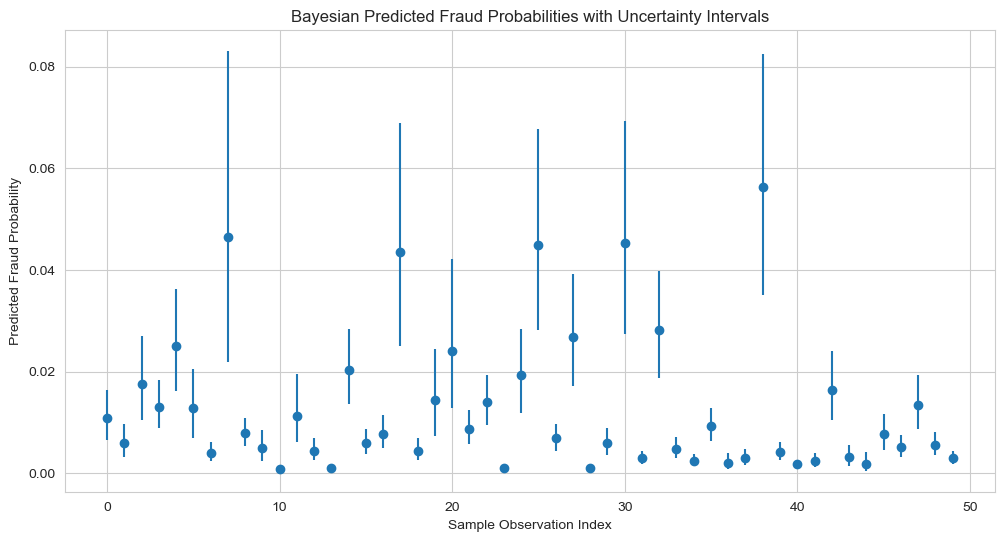

In [82]:
sample_df = val_prob_intervals.head(50).copy().reset_index(drop=True)

plt.figure(figsize=(12, 6))
plt.errorbar(
    x=sample_df.index,
    y=sample_df["mean_prob"],
    yerr=[
        sample_df["mean_prob"] - sample_df["lower_prob"],
        sample_df["upper_prob"] - sample_df["mean_prob"]
    ],
    fmt="o"
)
plt.title("Bayesian Predicted Fraud Probabilities with Uncertainty Intervals")
plt.xlabel("Sample Observation Index")
plt.ylabel("Predicted Fraud Probability")
plt.show()

- Plots a sample of transactions with their predicted fraud probabilities and uncertainty bars.
- clearest visual demonstration of Bayesian inference
    - narrow bars = high confidence
    - wide bars = uncertainty

### Final comparison

* model types: **Frequentist vs Bayesian**
* threshold policies: **default, F1-optimized, precision-constrained, cost-optimized**
* performance on the **held-out test set**

# Key results

## 1. Best overall F1

- weighted_best_f1 → F1 = 0.786
- Precision = 0.803
- Recall = 0.770

### Interpretation

* Best balance between precision and recall
* Strong fraud detection with manageable false positives
* This is your **top-performing model by F1**

**The weighted logistic regression with threshold tuning achieved the best F1 score, demonstrating that class weighting combined with proper threshold selection can significantly improve balanced fraud detection performance.**


## 2. Strong simple baseline

- baseline_05 → F1 = 0.731
- Precision = 0.817
- Recall = 0.662

### Interpretation

* Very strong performance without tuning
* High precision → fewer false alarms
* Lower recall → misses more fraud

**The baseline logistic regression performed strongly even without threshold tuning, highlighting that simpler models can be highly effective when features are informative.**

## 3. Best Bayesian performance

- bayes_target_precision → F1 = 0.717
- Precision = 0.732
- Recall = 0.703

### Interpretation

* Bayesian model is competitive
* Slightly lower F1 than top frequentist models
* More balanced than default Bayesian threshold


## 4. Bayesian vs Frequentist

### Frequentist models:

* Slightly higher peak performance (F1)
* Better calibration (lower Brier score)
* Simpler to deploy

### Bayesian models:

* Slightly lower F1
* Provide **uncertainty estimates**
* More flexible for decision-making

## 5. Cost-sensitive policies

### Example:

- bayes_best_cost → Recall = 0.797
- baseline_best_cost → Recall = 0.851

### Interpretation

* These policies prioritize catching fraud
* Accept more false positives
* Lower F1, but potentially better for business

Cost-optimized thresholds prioritize minimizing missed fraud, which is often more expensive than false alarms. This reflects a real-world tradeoff rather than purely optimizing statistical metrics.


## 6. Worst model

- weighted_05 → F1 = 0.12
- Precision = 0.064

### Interpretation

* Extremely poor precision
* Too many false positives

The weighted model performed very poorly at the default threshold, which demonstrates that threshold selection is critical in imbalanced classification problems.

👉 Threshold choice matters as much as model choice

👉 Class weighting improves recall but requires threshold tuning

👉 Bayesian models add uncertainty, not necessarily higher accuracy

👉 Different policies optimize different business goals

### Which model would you deploy?

It depends on the business objective. If I want balanced performance, I would choose the weighted logistic regression with the F1-optimized threshold. If minimizing false positives is critical, I might choose the baseline model. If uncertainty is important for downstream decision-making or human review, I would consider the Bayesian model.


# MCMC

In [ ]:
'''
with pm.Model() as bayes_logistic_model:
    
    # Data containers
    X_data = pm.Data("X_data", X_train_np)
    y_data = pm.Data("y_data", y_train_np)
    
    # Global shrinkage prior
    sigma_beta = pm.HalfNormal("sigma_beta", sigma=1.0)
    
    # Priors
    #alpha = pm.Normal("alpha", mu=0.0, sigma=5.0)
    alpha = pm.Normal("alpha", mu=0.0, sigma=2.0)
    #beta = pm.Normal("beta", mu=0.0, sigma=sigma_beta, shape=n_features)
    beta = pm.Normal("beta", mu=0.0, sigma=0.5, shape=n_features)
    # Linear predictor
    logits = alpha + pm.math.dot(X_data, beta)
    
    # Probability
    p = pm.Deterministic("p", pm.math.sigmoid(logits))
    
    # Likelihood
    y_obs = pm.Bernoulli("y_obs", p=p, observed=y_data)
'''

In [ ]:
'''
with bayes_logistic_model:
    trace = pm.sample(
        draws=300,
        tune=500,
        chains=4,
        cores=1,
        target_accept=0.99,
        init="adapt_diag",
        random_seed=42,
        return_inferencedata=True
    )
'''

In [ ]:
'''
with bayes_logistic_model:
    trace = pm.sample(
        draws=500,
        tune=1500,
        chains=2,
        cores=1,
        target_accept=0.99,
        init="adapt_diag",
        random_seed=42,
        return_inferencedata=True
    )
'''

In [137]:
'''
with bayes_logistic_model:
    trace = pm.sample(
        draws=500,
        tune=1500,
        chains=4,
        cores=1,
        target_accept=0.99,
        init="adapt_diag",
        random_seed=42,
        return_inferencedata=True
    )
'''

'\nwith bayes_logistic_model:\n    trace = pm.sample(\n        draws=500,\n        tune=1500,\n        chains=4,\n        cores=1,\n        target_accept=0.99,\n        init="adapt_diag",\n        random_seed=42,\n        return_inferencedata=True\n    )\n'